In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from heston.pinn.heston_pinn_nd import HestonMultiAssetPINN
from heston.tree import HestonTreeFast
from config.heston_nd import *

## Load models

### PINNs

In [20]:
seeds = [43]
pinns = []

for seed in seeds:
    pinn = HestonMultiAssetPINN(model_config, seed)
    pinn.set_params(K, r, T, kappa, theta, sigma_bar, sigmas, corr, rho_cross, S_min, S_max, V_min, V_max)
    pinns.append(pinn)
    pinn.load(f'../../models/heston_pinn_nd/{seed}.pth')

### Tree

#### One dimensional reduction

In [21]:
A = np.sum(np.square(sigmas))
b = corr.T @ corr
B = np.sum(np.square(b))

r_1d = n_assets * r + 0.5 * v0 * (B - A)
kappa_1d = kappa
theta_1d = B * theta
sigma_bar_1d = np.sqrt(B) * sigma_bar

n = 100
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.01
S0_max = S0 * 3

rho = np.mean(rho_cross)

heston_tree = HestonTreeFast(n, mz, mv, K, T, r_1d, kappa_1d, theta_1d, sigma_bar_1d, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min**2, S0_max=S0_max**2,
                       option_type="put", exercise_type="american")


## Comparing PINN with Tree

### Vary $S_1$, $S_2$, fix $V=0.04$ and $t=0$

In [22]:
resolution = 100

V = v0
S1s = np.linspace(S0_min, S0_max, resolution)
S2s = np.linspace(S0_min, S0_max, resolution)
S1_grid, S2_grid = np.meshgrid(S1s, S2s)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)
t = np.zeros((S_grid.shape[0], 1))  # Time to maturity is 0 at maturity

# PINN prices
nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
S_tensor = torch.tensor(S_grid, dtype=torch.float32)
t_tensor = torch.tensor(t, dtype=torch.float32)
V_tensor = torch.tensor([[V]], dtype=torch.float32).repeat(S_tensor.shape[0], 1)

for i, pinn in enumerate(pinns):
    nn_prices_all[:, :, i] = pinn.predict(t_tensor, S_tensor, V_tensor).numpy().reshape(resolution, resolution)

nn_prices = nn_prices_all.mean(axis=-1)

# Heston tree prices
S_prod = S_grid[:, 0] * S_grid[:, 1]
ht_prices = heston_tree.price(V, S_prod, 0).reshape(resolution, resolution)

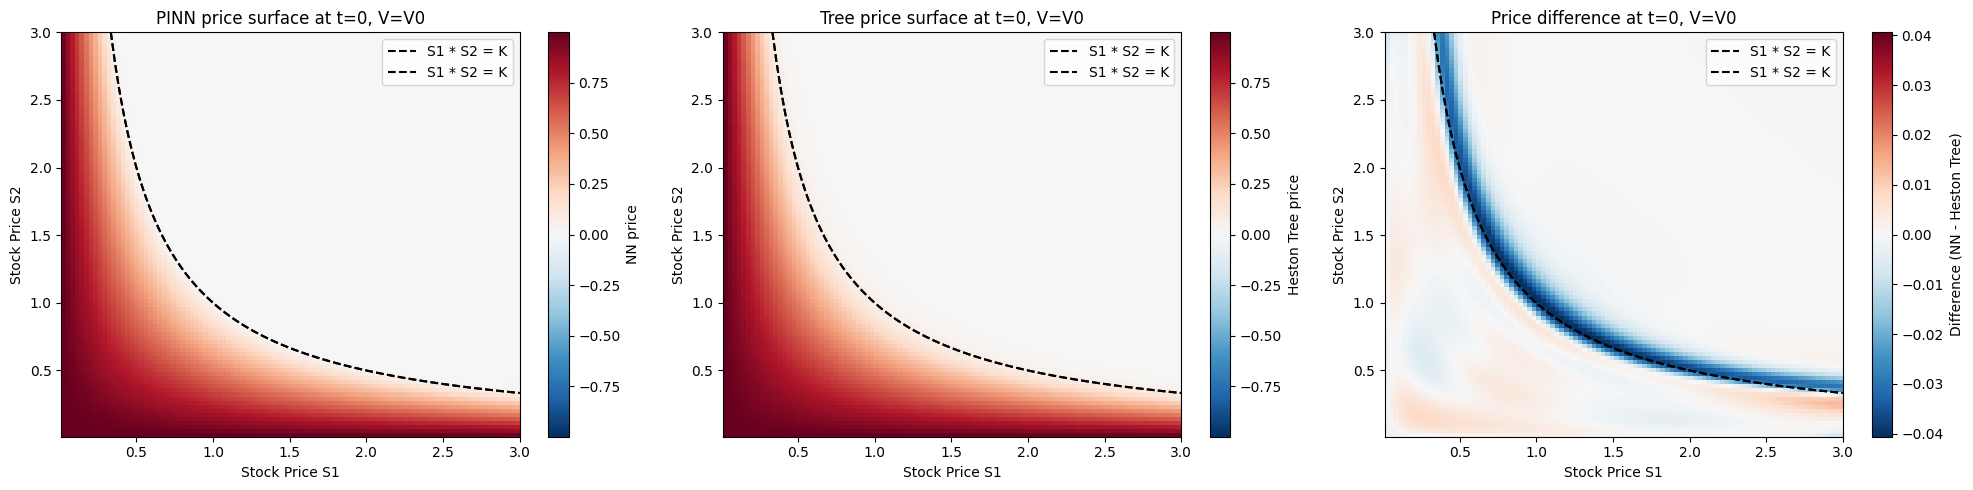

In [23]:
# Plotting the results
Xs = np.linspace(K / S_max, S_max, 100)
Ys = K / Xs

plt.figure(figsize=(20, 5))

# Plot the neural network price surface
plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('PINN price surface at t=0, V=V0')
plt.legend()

plt.subplot(1, 3, 2)
vmax = np.abs(ht_prices).max()
vmin = -vmax
im = plt.imshow(ht_prices, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Heston Tree price')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Tree price surface at t=0, V=V0')
plt.legend()

plt.subplot(1, 3, 3)
diff = nn_prices - ht_prices

vmax = np.abs(diff).max()
vmin = -vmax
im = plt.imshow(diff, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Difference (NN - Heston Tree)')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Price difference at t=0, V=V0')
plt.legend()

plt.tight_layout()
plt.show()

### Keep $S_1 = S_2$, vary $V$, fix $t=0$

In [24]:
resolution = 100

Ss = np.linspace(S0_min, S0_max, resolution)
Vs = np.linspace(V0_min, V0_max, resolution)
S_grid_1d, V_grid = np.meshgrid(Ss, Vs)  # both shape (resolution, resolution)

S_pairs = np.stack([S_grid_1d.ravel(), S_grid_1d.ravel()], axis=-1)  # S1 = S2
V_flat = V_grid.ravel().reshape(-1, 1)
t = np.zeros((S_pairs.shape[0], 1))

# PINN prices
S_tensor = torch.tensor(S_pairs, dtype=torch.float32)
t_tensor = torch.tensor(t, dtype=torch.float32)
V_tensor = torch.tensor(V_flat, dtype=torch.float32)

nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
for i, pinn in enumerate(pinns):
    nn_prices_all[:, :, i] = pinn.predict(t_tensor, S_tensor, V_tensor).numpy().reshape(resolution, resolution)

nn_prices_sv = nn_prices_all.mean(axis=-1)

# Heston tree prices
S_prod = S_pairs[:, 0] * S_pairs[:, 1]  # = S^2

ht_prices_sv = heston_tree.price(V_flat.ravel(), S_prod, 0).reshape(resolution, resolution)

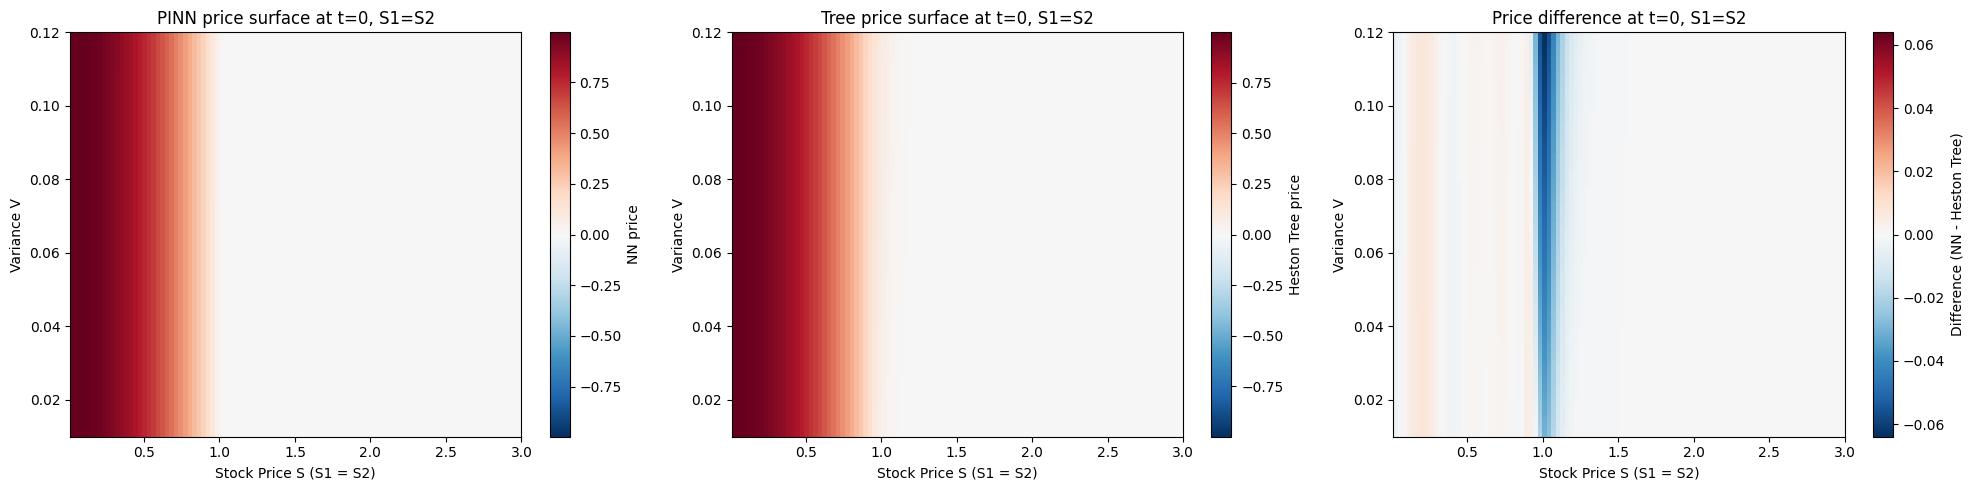

In [25]:
# Plotting
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices_sv).max()
im = plt.imshow(nn_prices_sv, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Stock Price S (S1 = S2)')
plt.ylabel('Variance V')
plt.title('PINN price surface at t=0, S1=S2')

plt.subplot(1, 3, 2)
vmax = np.abs(ht_prices_sv).max()
im = plt.imshow(ht_prices_sv, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='Heston Tree price')
plt.xlabel('Stock Price S (S1 = S2)')
plt.ylabel('Variance V')
plt.title('Tree price surface at t=0, S1=S2')

plt.subplot(1, 3, 3)
diff = nn_prices_sv - ht_prices_sv
vmax = np.abs(diff).max()
im = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='Difference (NN - Heston Tree)')
plt.xlabel('Stock Price S (S1 = S2)')
plt.ylabel('Variance V')
plt.title('Price difference at t=0, S1=S2')

plt.tight_layout()
plt.show()

### Keep $S1 = S2 = \sqrt K$, vary $V$, vary $t$ 

In [26]:
resolution = 100

S_atm = np.sqrt(K)  # S1 = S2 = sqrt(K), so S1*S2 = K
Vs = np.linspace(V0_min, V0_max, resolution)
ts = np.linspace(0, 1 - 1e-4, resolution)  # time to maturity

# meshgrid: rows = t index, cols = V index
V_grid, t_grid = np.meshgrid(Vs, ts)
V_flat = V_grid.ravel().reshape(-1, 1)
t_flat = t_grid.ravel().reshape(-1, 1)
S_flat = np.full((len(V_flat), 2), S_atm)

# PINN prices
S_tensor = torch.tensor(S_flat, dtype=torch.float32)
t_tensor = torch.tensor(t_flat, dtype=torch.float32)
V_tensor = torch.tensor(V_flat, dtype=torch.float32)

nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
for i, pinn in enumerate(pinns):
    nn_prices_all[:, :, i] = pinn.predict(t_tensor, S_tensor, V_tensor).numpy().reshape(resolution, resolution)

nn_prices_vt = nn_prices_all.mean(axis=-1)

# Tree prices: batch over V at each time step k = round(t * n)
S_prod = S_atm ** 2  # = K
ht_prices_vt = np.zeros((resolution, resolution))
for j, t_val in enumerate(ts):
    k = int(round(t_val * n))
    k = min(k, n - 1)  # ensure k does not exceed n-1
    ht_prices_vt[j, :] = heston_tree.price(Vs, S_prod, k)

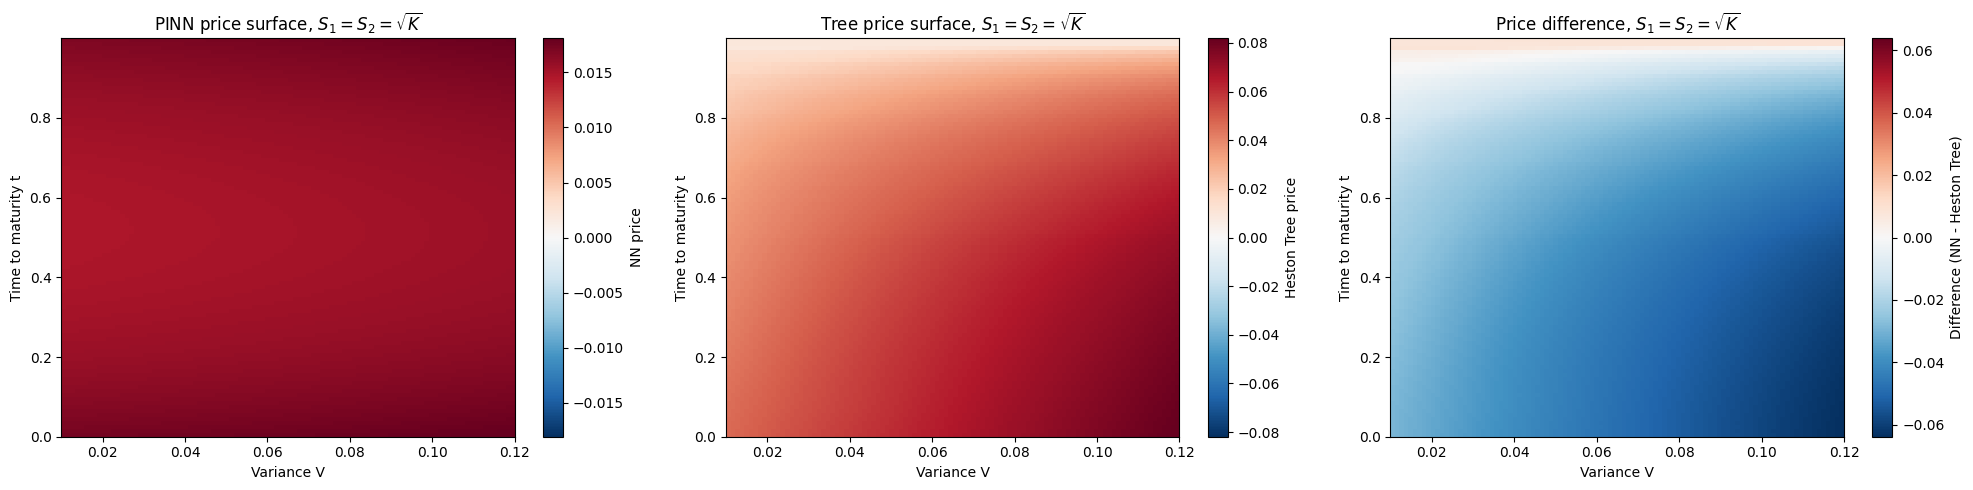

In [27]:
# Plotting
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices_vt).max()
im = plt.imshow(nn_prices_vt, extent=[Vs[0], Vs[-1], ts[0], ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Variance V')
plt.ylabel('Time to maturity t')
plt.title(r'PINN price surface, $S_1=S_2=\sqrt{K}$')

plt.subplot(1, 3, 2)
vmax = np.abs(ht_prices_vt).max()
im = plt.imshow(ht_prices_vt, extent=[Vs[0], Vs[-1], ts[0], ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='Heston Tree price')
plt.xlabel('Variance V')
plt.ylabel('Time to maturity t')
plt.title(r'Tree price surface, $S_1=S_2=\sqrt{K}$')

plt.subplot(1, 3, 3)
diff = nn_prices_vt - ht_prices_vt
vmax = np.abs(diff).max()
im = plt.imshow(diff, extent=[Vs[0], Vs[-1], ts[0], ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='Difference (NN - Heston Tree)')
plt.xlabel('Variance V')
plt.ylabel('Time to maturity t')
plt.title(r'Price difference, $S_1=S_2=\sqrt{K}$')

plt.tight_layout()
plt.show()